In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [4]:
DATA_PATH = Path("../data/processed/master_dataset.csv")

In [5]:
df = pd.read_csv(DATA_PATH)

In [6]:
df.shape

(32, 55)

In [7]:
df.head()

,uni_id,uni_name,UNITID,prog_name,prog_application,prog_longevity_score,prog_commit_score,prog_support_score,prog_website_score,prog_feedback_web,...,CBSA_FIPS,CBSA_Name,Pell_PCT,UnderRepMinority_PCT_22_23,Access_Ratio,Access_Geo_Flag,8Yr_MedEarnings,SAECCompEarnings,Earnings_Ratio,SAEC25
0,U01,University of Central Missouri,176965,Friendship Family program,email,1.0,1.0,1,1,1,...,47660,"Warrensburg, MO",0.3191,0.2078,1.43,NaN,45855.0,31558.121990,1.45,"Higher Access, Medium Earnings"
1,U02,Truman State University,178615,International Friends,Google Form,2.0,2.0,3,3,1,...,28860,"Kirksville, MO",0.1897,0.1061,0.75,NaN,48947.0,36814.284424,1.33,"Lower Access, Medium Earnings"
2,U03,Carnegie Mellon University,211440,International Neighbors program,Google Form,2.0,3.0,1,4,2,...,38300,"Pittsburgh, PA",0.1533,0.2638,0.64,NaN,105524.0,40824.697384,2.58,"Lower Access, Higher Earnings"
3,U04,Macalester College,173902,Formign Links Across the Global,Google Form,4.0,3.0,3,4,4,...,33460,"Minneapolis-St. Paul-Bloomington, MN-WI",0.1741,0.2868,0.76,NaN,57106.0,41025.171582,1.39,"Lower Access, Medium Earnings"
4,U05,Kenyon College,203535,Friendship Family program,Google Form,2.0,3.0,2,3,1,...,34540,"Mount Vernon, OH",0.1012,0.1828,0.44,NaN,52468.0,40280.292706,1.30,"Lower Access, Medium Earnings"


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 55 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   uni_id                                32 non-null     str    
 1   uni_name                              32 non-null     str    
 2   UNITID                                32 non-null     int64  
 3   prog_name                             32 non-null     str    
 4   prog_application                      31 non-null     str    
 5   prog_longevity_score                  27 non-null     float64
 6   prog_commit_score                     31 non-null     float64
 7   prog_support_score                    32 non-null     int64  
 8   prog_website_score                    32 non-null     int64  
 9   prog_feedback_web                     32 non-null     int64  
 10  prog_orientaion                       32 non-null     int64  
 11  prog_tech_score                 

In [9]:
missing_pct = (
    df.isna()
    .mean()
    .mul(100)
    .sort_values(ascending = False)

)

missing_pct[missing_pct > 0]

Access_Geo_Flag                        100.000
uni_graduate_nonresident_enrollment     21.875
prog_feature                            21.875
uni_graduate_nonresident_pct            21.875
uni_graduate_enrollment                 21.875
prog_year-type                          15.625
prog_longevity_score                    15.625
prog_application                         3.125
prog_commit_score                        3.125
dtype: float64

In [10]:
ucm = df[df["UNITID"] == 176965]

ucm.T

,0
uni_id,U01
uni_name,University of Central Missouri
UNITID,176965
prog_name,Friendship Family program
prog_application,email
prog_longevity_score,1.0
prog_commit_score,1.0
prog_support_score,1
prog_website_score,1
prog_feedback_web,1


In [11]:
compare_cols = [
    "uni_total_enrollment",
    "uni_total_nonresident_pct",
    "uni_undergrad_nonresident_pct",
    "uni_graduate_nonresident_pct",
    "Pell_PCT",
    "Access_Ratio",
    "8Yr_MedEarnings"
]

df[compare_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
uni_total_enrollment,32.0,11284.906250,11698.787515,1417.000000,2599.250000,7516.500000,13614.750000,47980.000000
uni_total_nonresident_pct,32.0,9.175683,8.270994,0.208442,4.565725,7.323293,10.953334,42.006546
uni_undergrad_nonresident_pct,32.0,6.423775,5.325594,0.208442,2.396469,4.764809,9.599271,20.469799
uni_graduate_nonresident_pct,25.0,16.333317,16.692921,1.139089,3.617571,12.314887,20.896785,61.919211
Pell_PCT,32.0,0.269119,0.110447,0.101200,0.174000,0.259200,0.343325,0.526800
Access_Ratio,32.0,0.912187,0.273988,0.440000,0.695000,0.900000,1.117500,1.460000
8Yr_MedEarnings,32.0,54911.593750,14998.857363,33978.000000,45580.250000,51744.500000,58606.250000,105524.000000


In [12]:
for col in compare_cols:
    ucm_value = ucm[col].iloc[0]
    percentile = (df[col] <= ucm_value).mean() * 100
    
    print(
        col,
        "UCM =", round(ucm_value, 2),
        "Percentile =", round(percentile, 1)
    )

uni_total_enrollment UCM = 12857 Percentile = 75.0
uni_total_nonresident_pct UCM = 26.54 Percentile = 96.9
uni_undergrad_nonresident_pct UCM = 1.94 Percentile = 25.0
uni_graduate_nonresident_pct UCM = 61.92 Percentile = 78.1
Pell_PCT UCM = 0.32 Percentile = 71.9
Access_Ratio UCM = 1.43 Percentile = 96.9
8Yr_MedEarnings UCM = 45855.0 Percentile = 28.1


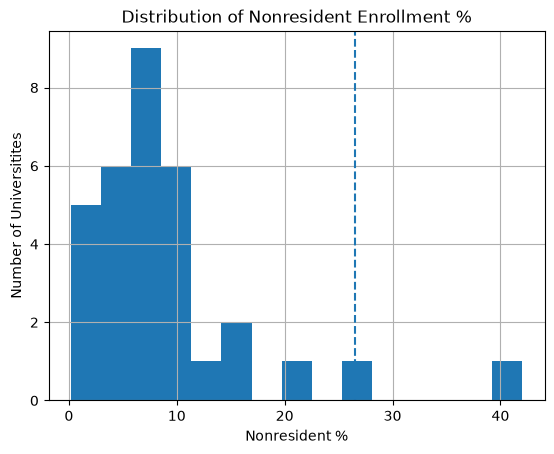

In [13]:
df["uni_total_nonresident_pct"].hist(bins=15)

plt.axvline(
    ucm["uni_total_nonresident_pct"].iloc[0],
    linestyle = "--"
)

plt.xlabel("Nonresident %")
plt.ylabel("Number of Universitites")
plt.title("Distribution of Nonresident Enrollment %")

plt.show()

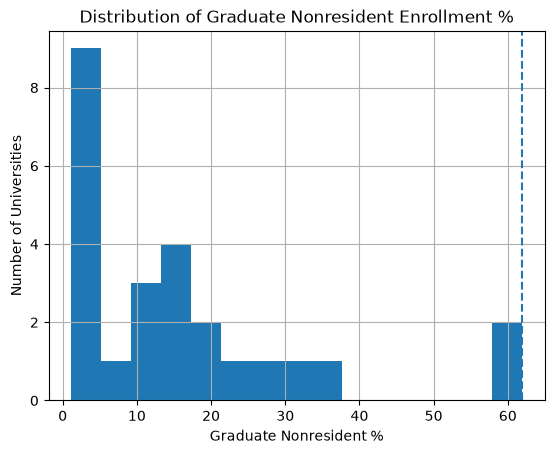

In [18]:
df["uni_graduate_nonresident_pct"].hist(bins=15)

plt.axvline(
    ucm["uni_graduate_nonresident_pct"].iloc[0],
    linestyle ="--")

plt.xlabel("Graduate Nonresident %")
plt.ylabel("Number of Universities")
plt.title("Distribution of Graduate Nonresident Enrollment %")

plt.show()


In [22]:
score_cols = [
    "prog_longevity_score",
    "prog_commit_score",
    "prog_support_score",
    "prog_website_score",
    "prog_tech_score",
    "prog_risk_score"
]

In [23]:
df[score_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
prog_longevity_score,27.0,2.407407,1.118352,1.0,1.5,2.0,3.00,4.0
prog_commit_score,31.0,2.548387,0.809885,1.0,2.0,3.0,3.00,4.0
prog_support_score,32.0,2.843750,0.807600,1.0,2.0,3.0,3.00,4.0
prog_website_score,32.0,3.125000,0.659912,1.0,3.0,3.0,3.25,4.0
prog_tech_score,32.0,2.375000,0.707107,1.0,2.0,2.0,3.00,4.0
prog_risk_score,32.0,2.593750,0.837021,1.0,2.0,2.0,3.00,4.0


In [24]:
for col in score_cols:
    print("\n", col)
    print(
        df[col]
        .value_counts(dropna=False)
        .sort_index()
    )


 prog_longevity_score
prog_longevity_score
1.0    7
2.0    8
3.0    6
4.0    6
NaN    5
Name: count, dtype: int64

 prog_commit_score
prog_commit_score
1.0     5
2.0     5
3.0    20
4.0     1
NaN     1
Name: count, dtype: int64

 prog_support_score
prog_support_score
1     2
2     7
3    17
4     6
Name: count, dtype: int64

 prog_website_score
prog_website_score
1     1
2     2
3    21
4     8
Name: count, dtype: int64

 prog_tech_score
prog_tech_score
1     3
2    15
3    13
4     1
Name: count, dtype: int64

 prog_risk_score
prog_risk_score
1     1
2    17
3     8
4     6
Name: count, dtype: int64


In [25]:
df["program_score_mean"] = df[score_cols].mean(axis=1)

In [26]:
df[
    ["uni_name", "program_score_mean"]
].sort_values(
    "program_score_mean",
    ascending=False
)

,uni_name,program_score_mean
16,Oregon State University,3.666667
3,Macalester College,3.500000
12,University of Idaho,3.400000
23,The University of Montana,3.166667
17,University of St Thomas,3.000000
18,University of St Thomas,3.000000
9,Youngstown State University,3.000000
22,University of Oklahoma-Norman Campus,3.000000
25,University of Houston,3.000000
24,University of Arkansas,2.833333


In [38]:
university_cols = [
    "uni_total_enrollment",
    "uni_total_nonresident_pct",
    "uni_undergrad_nonresident_pct",
    "uni_graduate_nonresident_pct",
    "Pell_PCT",
    "Access_Ratio",
    "8Yr_MedEarnings",
    "Earnings_Ratio"
]

In [39]:
analysis_cols = university_cols + score_cols

correlation = df[analysis_cols].corr()

correlation

,uni_total_enrollment,uni_total_nonresident_pct,uni_undergrad_nonresident_pct,uni_graduate_nonresident_pct,Pell_PCT,Access_Ratio,8Yr_MedEarnings,Earnings_Ratio,prog_longevity_score,prog_commit_score,prog_support_score,prog_website_score,prog_tech_score,prog_risk_score
uni_total_enrollment,1.000000,0.006836,-0.302861,0.384932,0.135089,0.076073,0.130590,0.233371,0.198764,0.107440,-0.094243,0.243983,0.205276,0.228000
uni_total_nonresident_pct,0.006836,1.000000,0.702105,0.854212,-0.356253,-0.209134,0.605576,0.592717,-0.062646,-0.126758,-0.550300,0.012907,-0.260168,-0.086410
uni_undergrad_nonresident_pct,-0.302861,0.702105,1.000000,0.305620,-0.568998,-0.527373,0.517502,0.377343,0.141741,0.077674,-0.209600,0.238574,-0.053787,0.088230
uni_graduate_nonresident_pct,0.384932,0.854212,0.305620,1.000000,-0.028439,0.049683,0.417605,0.491701,-0.193708,-0.375591,-0.586756,-0.086873,-0.362906,-0.179640
Pell_PCT,0.135089,-0.356253,-0.568998,-0.028439,1.000000,0.775659,-0.574058,-0.351071,-0.018852,-0.131142,0.125310,-0.106520,-0.179025,0.110105
Access_Ratio,0.076073,-0.209134,-0.527373,0.049683,0.775659,1.000000,-0.517800,-0.386094,0.138496,-0.007258,0.091981,-0.256689,-0.172539,-0.125407
8Yr_MedEarnings,0.130590,0.605576,0.517502,0.417605,-0.574058,-0.517800,1.000000,0.923783,-0.032461,0.191043,-0.345622,0.334911,0.146362,-0.052297
Earnings_Ratio,0.233371,0.592717,0.377343,0.491701,-0.351071,-0.386094,0.923783,1.000000,-0.077665,0.236956,-0.398357,0.275416,0.168276,0.030949
prog_longevity_score,0.198764,-0.062646,0.141741,-0.193708,-0.018852,0.138496,-0.032461,-0.077665,1.000000,0.295559,-0.023864,0.161413,0.321219,0.188247
prog_commit_score,0.107440,-0.126758,0.077674,-0.375591,-0.131142,-0.007258,0.191043,0.236956,0.295559,1.000000,-0.012946,0.417859,0.311775,0.249083


In [42]:
program_correlations = correlation.loc[
    university_cols,
    score_cols
]

program_correlations

,prog_longevity_score,prog_commit_score,prog_support_score,prog_website_score,prog_tech_score,prog_risk_score
uni_total_enrollment,0.198764,0.107440,-0.094243,0.243983,0.205276,0.228000
uni_total_nonresident_pct,-0.062646,-0.126758,-0.550300,0.012907,-0.260168,-0.086410
uni_undergrad_nonresident_pct,0.141741,0.077674,-0.209600,0.238574,-0.053787,0.088230
uni_graduate_nonresident_pct,-0.193708,-0.375591,-0.586756,-0.086873,-0.362906,-0.179640
Pell_PCT,-0.018852,-0.131142,0.125310,-0.106520,-0.179025,0.110105
Access_Ratio,0.138496,-0.007258,0.091981,-0.256689,-0.172539,-0.125407
8Yr_MedEarnings,-0.032461,0.191043,-0.345622,0.334911,0.146362,-0.052297
Earnings_Ratio,-0.077665,0.236956,-0.398357,0.275416,0.168276,0.030949


In [ ]:
correlation_pairs = (
    program_correlations
    .stack()
    .reset_index()
)

correlation_pairs.columns = [
    "university_variable",
    "program_variable",
    "correlation"
]

correlation_pairs["abs_correlation"] = (
    correlation_paris["correlation"].abs()
)

correlation_pairs.sort_values(
    "abs_correlation",
    ascending=False
).head(15)

,university_variable,program_variable,correlation,abs_correlation
20,uni_graduate_nonresident_pct,prog_support_score,-0.586756,0.586756
8,uni_total_nonresident_pct,prog_support_score,-0.550300,0.550300
44,Earnings_Ratio,prog_support_score,-0.398357,0.398357
19,uni_graduate_nonresident_pct,prog_commit_score,-0.375591,0.375591
22,uni_graduate_nonresident_pct,prog_tech_score,-0.362906,0.362906
38,8Yr_MedEarnings,prog_support_score,-0.345622,0.345622
39,8Yr_MedEarnings,prog_website_score,0.334911,0.334911
45,Earnings_Ratio,prog_website_score,0.275416,0.275416
10,uni_total_nonresident_pct,prog_tech_score,-0.260168,0.260168
33,Access_Ratio,prog_website_score,-0.256689,0.256689


In [48]:
spearman_corr = df[
    university_cols + score_cols
].corr(method = "spearman")

spearman_program = spearman_corr.loc[
    university_cols,
    score_cols
]

spearman_program

,prog_longevity_score,prog_commit_score,prog_support_score,prog_website_score,prog_tech_score,prog_risk_score
uni_total_enrollment,0.012621,0.092185,-0.060024,0.142174,0.103010,0.184233
uni_total_nonresident_pct,0.064999,-0.226790,-0.299718,0.068462,-0.234589,-0.116177
uni_undergrad_nonresident_pct,0.221187,0.055216,-0.192919,0.149173,-0.028167,0.101882
uni_graduate_nonresident_pct,-0.125117,-0.404282,-0.276306,0.151814,-0.161654,-0.023630
Pell_PCT,0.072257,-0.095029,0.119646,-0.096678,-0.155722,0.141144
Access_Ratio,0.146518,-0.001778,0.175635,-0.127249,-0.116745,-0.123080
8Yr_MedEarnings,0.076358,0.271342,-0.238489,0.425647,0.210849,-0.043088
Earnings_Ratio,0.010731,0.279010,-0.257431,0.396228,0.244314,0.059112


In [ ]:
spearman_pairs = (
    spearman_program
    .stack()
    .reset_index()
)

spearman_pairs.columns = [
    "university_variable",
    "program_variable",
    "correlation"
]

spearman_pairs["abs_correlation"] = (
    spearman_paris["correlation"].abs()
)

spearman_pairs.sort_values(
    "abs_correlation",
    ascending=False
).head(15)

,university_variable,program_variable,correlation,abs_correlation
39,8Yr_MedEarnings,prog_website_score,0.425647,0.425647
19,uni_graduate_nonresident_pct,prog_commit_score,-0.404282,0.404282
45,Earnings_Ratio,prog_website_score,0.396228,0.396228
8,uni_total_nonresident_pct,prog_support_score,-0.299718,0.299718
43,Earnings_Ratio,prog_commit_score,0.279010,0.279010
20,uni_graduate_nonresident_pct,prog_support_score,-0.276306,0.276306
37,8Yr_MedEarnings,prog_commit_score,0.271342,0.271342
44,Earnings_Ratio,prog_support_score,-0.257431,0.257431
46,Earnings_Ratio,prog_tech_score,0.244314,0.244314
38,8Yr_MedEarnings,prog_support_score,-0.238489,0.238489


In [53]:
check_cols = [
    "8Yr_MedEarnings",
    "Earnings_Ratio",
    "uni_total_nonresident_pct",
    "uni_graduate_nonresident_pct",
    "prog_website_score",
    "prog_commit_score",
    "prog_support_score"
]

df[check_cols].notna().sum()

8Yr_MedEarnings                 32
Earnings_Ratio                  32
uni_total_nonresident_pct       32
uni_graduate_nonresident_pct    25
prog_website_score              32
prog_commit_score               31
prog_support_score              32
dtype: int64

In [59]:
pairs_to_check = [
    ("8Yr_MedEarnings", "prog_website_score"),
    ("uni_graduate_nonresident_pct", "prog_commit_score"),
    ("Earnings_Ratio", "prog_website_score"),
    ("uni_total_nonresident_pct", "prog_support_score"),
    ("uni_graduate_nonresident_pct", "prog_support_score")
]

In [60]:
for x, y in pairs_to_check:
    n = df[[x, y]].dropna().shape[0]
    print(f"{x} x {y}: n = {n}")

8Yr_MedEarnings x prog_website_score: n = 32
uni_graduate_nonresident_pct x prog_commit_score: n = 24
Earnings_Ratio x prog_website_score: n = 32
uni_total_nonresident_pct x prog_support_score: n = 32
uni_graduate_nonresident_pct x prog_support_score: n = 25


In [65]:
from scipy.stats import spearmanr
import pandas as pd

In [67]:
results = []

for x,y in pairs_to_check:
    temp = df[[x, y]].dropna()

    rho, p = spearmanr(
        temp[x],
        temp[y]
    )

    results.append({
        "university_variable": x,
        "program_variable": y,
        "n": len(temp),
        "spearman_rho": rho,
        "p_value": p
    })

    spearman_test= pd.DataFrame(results)


In [69]:
spearman_test

,university_variable,program_variable,n,spearman_rho,p_value
0,8Yr_MedEarnings,prog_website_score,32,0.425647,0.015148
1,uni_graduate_nonresident_pct,prog_commit_score,24,-0.404282,0.050065
2,Earnings_Ratio,prog_website_score,32,0.396228,0.024768
3,uni_total_nonresident_pct,prog_support_score,32,-0.299718,0.095601
4,uni_graduate_nonresident_pct,prog_support_score,25,-0.276306,0.181222


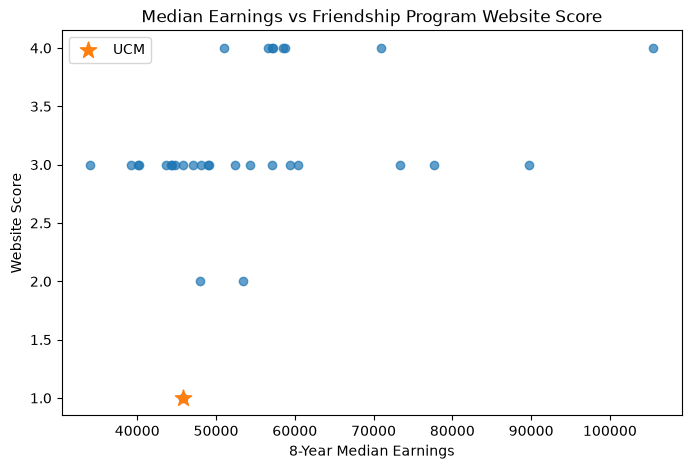

In [71]:
x = "8Yr_MedEarnings"
y = "prog_website_score"

temp = df[[x, y, "uni_name", "UNITID"]].dropna()

plt.figure(figsize=(8, 5))
plt.scatter(
    temp[x],
    temp[y],
    alpha=0.7
)

ucm_point = temp[
    temp["UNITID"] == 176965
]

plt.scatter(
    ucm_point[x],
    ucm_point[y],
    s = 150,
    marker = "*",
    label="UCM"
)

plt.xlabel("8-Year Median Earnings")
plt.ylabel("Website Score")
plt.title("Median Earnings vs Friendship Program Website Score")
plt.legend()
plt.show()

In [72]:
df.groupby("prog_website_score")[
    "8Yr_MedEarnings"
].agg(
    ["count", "median", "mean"]
)

,count,median,mean
prog_website_score,,,
1,1,45855.0,45855.000000
2,2,50746.5,50746.500000
3,21,48065.0,52105.285714
4,8,57886.0,64451.500000


In [73]:
df.groupby("prog_commit_score")[
    "uni_graduate_nonresident_pct"
].agg(["count", "median", "mean"])

,count,median,mean
prog_commit_score,,,
1.0,4,31.248673,32.008532
2.0,3,14.936709,11.498650
3.0,16,11.766418,15.112427
4.0,1,1.139089,1.139089


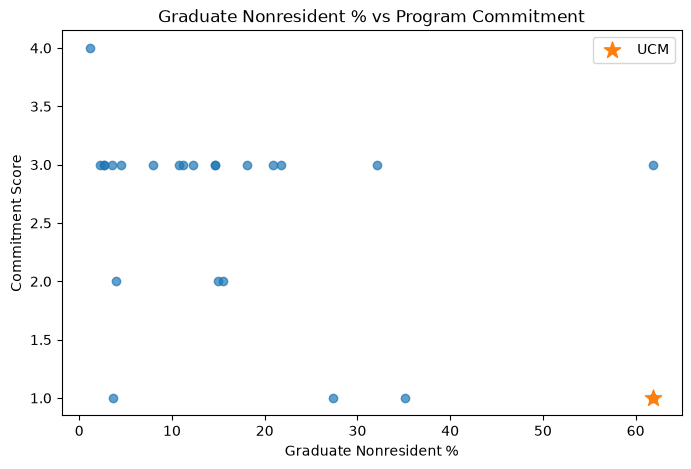

In [77]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["uni_graduate_nonresident_pct"],
    df["prog_commit_score"],
    alpha=0.7
)

ucm_point = df[df["UNITID"] == 176965]

plt.scatter(
    ucm_point["uni_graduate_nonresident_pct"],
    ucm_point["prog_commit_score"],
    s=150,
    marker="*",
    label="UCM"
)

plt.xlabel("Graduate Nonresident %")
plt.ylabel("Commitment Score")
plt.title("Graduate Nonresident % vs Program Commitment")
plt.legend()

plt.show()

In [80]:
similarity_cols = [
    "uni_total_enrollment",
    "uni_total_nonresident_pct",
    "uni_undergrad_nonresident_pct",
    "uni_graduate_nonresident_pct",
    "Pell_PCT",
    "LOCALE",
    "INSTSIZE",
    "CONTROL"
]

df[similarity_cols].head().T

,0,1,2,3,4
uni_total_enrollment,12857.000000,3664.000000,15888.000000,2138.000000,2249.00000
uni_total_nonresident_pct,26.538073,7.287118,42.006546,15.014032,9.51534
uni_undergrad_nonresident_pct,1.938291,7.687596,19.045683,15.014032,9.51534
uni_graduate_nonresident_pct,61.919211,4.010025,61.908119,NaN,NaN
Pell_PCT,0.319100,0.189700,0.153300,0.174100,0.10120
LOCALE,32.000000,33.000000,11.000000,11.000000,41.00000
INSTSIZE,4.000000,2.000000,4.000000,2.000000,2.00000
CONTROL,1.000000,1.000000,2.000000,2.000000,2.00000


In [84]:
numeric_similarity_cols = [
    "uni_total_enrollment",
    "uni_total_nonresident_pct",
    "uni_undergrad_nonresident_pct",
    "uni_graduate_nonresident_pct",
    "Pell_PCT"
]

df[numeric_similarity_cols].isna().sum()

uni_total_enrollment             0
uni_total_nonresident_pct        0
uni_undergrad_nonresident_pct    0
uni_graduate_nonresident_pct     7
Pell_PCT                         0
dtype: int64

In [85]:
similarity_df = df[
    ["UNITID", "uni_name"] + numeric_similarity_cols
].dropna().copy()

similarity_df.shape

(25, 7)

In [87]:
similarity_df[
    similarity_df["UNITID"] == 176965
].T

,0
UNITID,176965
uni_name,University of Central Missouri
uni_total_enrollment,12857
uni_total_nonresident_pct,26.538073
uni_undergrad_nonresident_pct,1.938291
uni_graduate_nonresident_pct,61.919211
Pell_PCT,0.3191


In [88]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    similarity_df[numeric_similarity_cols]
)

scaled_features[:5]

array([[-0.08806887,  2.08780703, -0.76064341,  2.78716405,  0.35456803],
       [-0.86907009, -0.15651116,  0.61939282, -0.75345757, -1.01419997],
       [ 0.169433  ,  3.89115529,  3.34573496,  2.78648586, -1.39923208],
       [-0.40283114, -0.09398713, -0.56180859, -0.10598601,  0.2530211 ],
       [-0.69142693, -0.45505397, -0.6140049 , -0.24569057,  0.60737758]])

In [91]:
from scipy.spatial.distance import euclidean

In [93]:
ucm_idx = similarity_df.index[
    similarity_df["UNITID"] == 176965
][0]

ucm_position = similarity_df.index.get_loc(ucm_idx)

ucm_vector = scaled_features[ucm_position]

similarity_df["distance_to_ucm"] = [
    euclidean(row, ucm_vector)
    for row in scaled_features
]

In [94]:
similarity_ranking = (
    similarity_df
    .sort_values("distance_to_ucm")
)

similarity_ranking[
    [
        "uni_name",
        "distance_to_ucm",
        "uni_total_enrollment",
        "uni_total_nonresident_pct",
        "uni_undergrad_nonresident_pct",
        "uni_graduate_nonresident_pct",
        "Pell_PCT"
    ]
].head(10)

,uni_name,distance_to_ucm,uni_total_enrollment,uni_total_nonresident_pct,uni_undergrad_nonresident_pct,uni_graduate_nonresident_pct,Pell_PCT
0,University of Central Missouri,0.000000,12857,26.538073,1.938291,61.919211,0.3191
13,Binghamton University,2.596176,18816,10.884354,4.028904,35.133832,0.2748
20,University of Memphis,3.520141,20276,7.447228,1.756500,27.363515,0.4708
6,Northwest Missouri State University,3.644100,9152,7.823427,2.766648,14.599847,0.3095
9,Youngstown State University,3.873329,12204,11.160275,9.851064,15.549215,0.3545
21,Case Western Reserve University,3.881928,12475,16.352705,11.473652,21.708424,0.1734
29,Johnson & Wales University-Providence,3.970040,4303,3.997211,2.891505,14.936709,0.3046
12,University of Idaho,3.988411,12286,6.755657,5.629831,10.730088,0.3120
7,Pittsburg State University,4.014201,5755,4.726325,2.549195,12.314887,0.3430
18,University of St Thomas,4.117714,4301,5.975355,4.517088,11.217949,0.3975


In [95]:
program_cols = [
    "UNITID",
    "prog_longevity_score",
    "prog_commit_score",
    "prog_support_score",
    "prog_website_score",
    "prog_tech_score",
    "prog_risk_score",
    "program_score_mean",
    "CONTROL",
    "LOCALE",
    "INSTSIZE"
]

comparison = similarity_ranking.merge(
    df[program_cols],
    on="UNITID",
    how="left"
)

In [96]:
comparison[
    [
        "uni_name",
        "distance_to_ucm",
        "CONTROL",
        "LOCALE",
        "INSTSIZE",
        "prog_longevity_score",
        "prog_commit_score",
        "prog_support_score",
        "prog_website_score",
        "prog_tech_score",
        "prog_risk_score",
        "program_score_mean"
    ]
].head(10)

,uni_name,distance_to_ucm,CONTROL,LOCALE,INSTSIZE,prog_longevity_score,prog_commit_score,prog_support_score,prog_website_score,prog_tech_score,prog_risk_score,program_score_mean
0,University of Central Missouri,0.000000,1,32,4,1.0,1.0,1,1,1,1,1.000000
1,Binghamton University,2.596176,1,22,4,3.0,1.0,2,3,2,2,2.166667
2,University of Memphis,3.520141,1,11,5,1.0,1.0,4,3,2,2,2.166667
3,Northwest Missouri State University,3.644100,1,33,3,3.0,3.0,3,3,1,2,2.500000
4,Youngstown State University,3.873329,1,13,4,NaN,2.0,4,3,2,4,3.000000
5,Case Western Reserve University,3.881928,2,11,4,1.0,3.0,2,3,3,3,2.500000
6,Johnson & Wales University-Providence,3.970040,2,12,2,2.0,2.0,3,3,2,2,2.333333
7,University of Idaho,3.988411,1,32,4,NaN,3.0,4,3,3,4,3.400000
8,Pittsburg State University,4.014201,1,32,3,4.0,3.0,2,3,3,2,2.833333
9,University of St Thomas,4.117714,2,11,2,2.0,3.0,4,4,3,2,3.000000


In [97]:
df["same_control_as_ucm"] = (
    df["CONTROL"] == 1
).astype(int)

In [98]:
def locale_group(x):
    if 11 <= x <= 13:
        return "City"
    elif 21 <= x <= 23:
        return "Suburb"
    elif 31 <= x <= 33:
        return "Town"
    elif 41 <= x <= 43:
        return "Rural"
    else:
        return "Unknown"

df["locale_group"] = df["LOCALE"].apply(locale_group)

In [99]:
df[
    ["uni_name", "LOCALE", "locale_group"]
].head(10)

,uni_name,LOCALE,locale_group
0,University of Central Missouri,32,Town
1,Truman State University,33,Town
2,Carnegie Mellon University,11,City
3,Macalester College,11,City
4,Kenyon College,41,Rural
5,Grinnell College,33,Town
6,Northwest Missouri State University,33,Town
7,Pittsburg State University,32,Town
8,University of Nebraska at Kearney,32,Town
9,Youngstown State University,13,City


In [100]:
df["same_locale_as_ucm"] = (
    df["locale_group"] == "Town"
).astype(int)

In [102]:
same_type = df[
    (df["same_control_as_ucm"] == 1) &
    (df["same_locale_as_ucm"] == 1)
]

print("Same CONTROL + LOCALE:", len(same_type))

same_type[
    [
        "uni_name",
        "CONTROL",
        "LOCALE",
        "locale_group",
        "uni_total_enrollment"
    ]
]

Same CONTROL + LOCALE: 7


,uni_name,CONTROL,LOCALE,locale_group,uni_total_enrollment
0,University of Central Missouri,1,32,Town,12857
1,Truman State University,1,33,Town,3664
6,Northwest Missouri State University,1,33,Town,9152
7,Pittsburg State University,1,32,Town,5755
8,University of Nebraska at Kearney,1,32,Town,5881
12,University of Idaho,1,32,Town,12286
28,Missouri State University-West Plains,1,33,Town,1919


In [103]:
same_type_ranking = similarity_ranking[
    similarity_ranking["UNITID"].isin(same_type["UNITID"])
].copy()

same_type_ranking[
    [
        "uni_name",
        "distance_to_ucm",
        "uni_total_enrollment",
        "uni_total_nonresident_pct",
        "uni_undergrad_nonresident_pct",
        "uni_graduate_nonresident_pct",
        "Pell_PCT"
    ]
].sort_values("distance_to_ucm")

,uni_name,distance_to_ucm,uni_total_enrollment,uni_total_nonresident_pct,uni_undergrad_nonresident_pct,uni_graduate_nonresident_pct,Pell_PCT
0,University of Central Missouri,0.000000,12857,26.538073,1.938291,61.919211,0.3191
6,Northwest Missouri State University,3.644100,9152,7.823427,2.766648,14.599847,0.3095
12,University of Idaho,3.988411,12286,6.755657,5.629831,10.730088,0.3120
7,Pittsburg State University,4.014201,5755,4.726325,2.549195,12.314887,0.3430
8,University of Nebraska at Kearney,4.662735,5881,4.931134,6.432471,1.139089,0.3443
1,Truman State University,4.686252,3664,7.287118,7.687596,4.010025,0.1897


In [110]:
ef_raw = pd.read_csv("../data/raw/ef2024a.csv")

In [112]:
ef_international = ef_raw[
    ef_raw["EFALEVEL"] == 1
][
    ["UNITID", "EFTOTLT", "EFNRALT"]
].copy()

In [127]:
ef_international = ef_international.rename(
    columns={
        "EFTOTLT": "uni_total_enrollment_check",
        "EFNRALT": "uni_international_enrollment"
    }
)